# NFCI-Conditions — a quantitative teardown 🔬
### Contemporaneous vs forward decomposition · tight-week conditional returns · a Welch *t* + placebo null · a timing backtest split into vol vs CAGR · a synthetic contemporaneous-isn't-predictive control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Step_out_of_stocks%3F: Misattributed](https://img.shields.io/badge/Step_out_of_stocks%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things the "step out when tight" pitch fuses: a **mechanical contemporaneous** link (the index embeds equity vol, so tight weeks *are* down weeks — near-tautological, untradable) from the **forward** link (the only thing a trader can act on). The decisive object is not the eye-catching same-week correlation (strongly negative, as advertised) but the **forward** test: with a one-week execution lag the predictive edge is correctly signed yet statistically indistinguishable from noise — and the timing rule's Sharpe bump is **volatility reduction**, not alpha.

> ⚠️ **Data + proxy note.** The true Chicago Fed NFCI isn't reachable here (FRED times out); we build a transparent **proxy** — a z-scored blend of equity vol (`^VIX`), rates vol (`^MOVE`), an IG-vs-Treasury credit spread (`LQD`/`IEF`) and broad-dollar momentum (`UUP`), **high = tight** (NFCI's sign). It is narrower/noisier and **built partly from equity vol** — so the contemporaneous tautology is shared with the real index; both named on the Signal axis. Real data: yfinance weekly closes, 2002→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nfci_conditions import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real conditions-proxy cache present:", HAVE_REAL,
      "| weeks:", (0 if F is None else len(F)),
      "| tight weeks:", (0 if F is None else int(st.tight_mask(F['fci']).sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-01-04', 'end': '2026-06-19', 'weeks': 1277, 'years': 24.5, 'n_tight': 271, 'pct_tight': 21, 'thresh': 0.5, 'contemp': -0.728, 'h1': (1, 271, 0.08, 53, 0.18, 57, -0.38, 0.264), 'h4': (4, 271, 0.66, 58, 0.7, 64, -0.09, 0.443), 'h13': (13, 269, 1.72, 62, 2.22, 70, -0.7, 0.134), 'timing': [(0, 90, 21, 0.71, 11.7, 0.53, 17.2, 0.18, 7.8, 7.8), (5, 90, 21, 0.69, 11.7, 0.53, 17.2, 0.16, 7.6, 7.8), (10, 90, 21, 0.67, 11.7, 0.53, 17.2, 0.15, 7.4, 7.8)], 'gap_full': 0.164, 'gap_ex2008': 0.091, 'robust': [(0.0, 483, 1.64, -1.17, 0.049), (0.5, 269, 1.72, -0.7, 0.134), (1.0, 136, 2.3, 0.08, 0.544)], 'syn': [(0.0, -0.27, 2.15, 2.06, 0.19, 0.592, -0.24), (0.006, -0.23, -0.47, 1.67, -3.94, 0.0, 0.46), (0.012, -0.17, -2.78, 1.62, -5.89, 0.0, 1.06)]}


real conditions-proxy cache present: True | weeks: 1277 | tight weeks: 271


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Same-week corr **-0.73** (mechanical). But the *forward* 13-week conditional mean **+1.72%** vs base **+2.22%**; Welch **t = -0.70**, placebo **p = 0.13** — correctly signed but **fails t ≥ 2**, and the point estimate **flips sign** (t = +0.08) at the tightest cut. |
| **Tradability** | `FRAGILE` | Step-out Sharpe **0.69** vs **0.53** at the **same CAGR (~7.7%)** — pure vol-cut (**17%→12%**). Bump **halves** ex-2008 (0.164→0.091); bootstrap CI straddles zero. |
| **Step out of stocks?** | `MISATTRIBUTED` | The apparent power is the index *being built from* the thing it claims to predict — contemporaneous coincidence dressed as forecast. A thermometer, not a barometer. |

> 💡 In plain words: the index correlates with stocks because it *contains* stocks. Strip that out and ask what tightness says about *next* week, and there's a small, correctly-signed, statistically-empty tilt — and a Sharpe bump that is entirely lower vol at the same return.

## 1 · The claim, steelmanned

Let $f_t$ be the weekly conditions index (z-scored, **high = tight**) and $\text{tight}_t \equiv \{f_t \ge \tau\}$ with $\tau = 0.5$ (~top quintile). The pitch is a regime switch: hold cash the week after a tight reading, else hold equities.

- **H₁ (it predicts).** $\mathbb{E}[r_{t+1\to t+1+H}\mid \text{tight}_t] < \mathbb{E}[r_{t+1\to t+1+H}]$ for forward horizon $H$ — tight weeks are *forward*-bearish relative to the base rate (the tradable direction).
- **H₂ (it's deployable).** The step-out rule earns a real, robust edge net of costs — not merely a higher Sharpe from lower volatility at the same return.
- **H₃ (the −0.73 is the signal).** The strong negative correlation reflects forecasting power, not the mechanical fact that the index embeds equity vol.

We find **H₁ correctly signed but not supported** (tiny, $|t| < 2$, sign-flips at the tightest cut), **H₂ rejected** (the Sharpe bump is pure vol-reduction at equal CAGR, halves ex-2008, CI through zero), **H₃ rejected** (the −0.73 is contemporaneous; the forward $t$ is ~−0.7). The lore is true exactly where it's uninformative (this week's coincidence) and unproven exactly where it would pay (next week's forecast).

## 2 · So what? — what rides on each answer

The whole teardown is one separation: a **contemporaneous** correlation (mechanical) against a **forward** conditional mean (tradable), the latter judged by its **standard error**.

$$\rho_{\text{contemp}} = \mathrm{corr}\!\left(\Delta f_t,\ r_t\right)\ \text{(no foresight)}, \qquad \widehat{\Delta}_H = \bar r^{\text{tight}}_H - \bar r^{\text{all}}_H,\quad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{tight}}/k + s^2_{\text{all}}/N\,}}.$$

$\rho_{\text{contemp}}$ is large and negative **by construction** — the index contains $r_t$ through its vol legs — so it decides *nothing*. The forward $\widehat{\Delta}_H$ is what a trader could harvest; with the tight weeks clustered into a few episodes, its standard error is large and a raw **win-rate** is the wrong lens (US forward returns are positive most of the time anyway). The honest small-sample instrument is a **placebo (randomization) test**: resample $k$ random weeks and ask how often chance is at least as bearish. That number decides the Signal axis. And for Tradability the decomposition is **Sharpe = return / vol** — a higher Sharpe at *equal CAGR* is lower vol, not more money.

## 3 · How we'd know — the protocol

- **Conditions proxy.** Weekly z-scored blend of `^VIX`, `^MOVE`, an `LQD`/`IEF` credit spread and `UUP` momentum (yfinance, 2002-01-04→2026-06-19, 1,277 weeks), **high = tight**. Explicit **proxy** for NFCI — narrower, noisier, *partly equity vol* (named on the axis).
- **Contemporaneous link.** $\mathrm{corr}(\Delta f_t, \log\text{-return}_t)$ — the mechanical same-week coincidence (must be strongly negative; predicts nothing).
- **Regime split.** Tight $\equiv f_t \ge +0.5z$ (**271** weeks, 21%).
- **Forward returns.** Enter the close **1 week after** the tight reading (no look-ahead), hold $H\in\{1,4,13\}$ weeks; drop windows that overrun the tape.
- **Null #1 (Welch t).** Conditional (tight-week) forward mean vs the unconditional overlapping-window mean.
- **Null #2 (placebo).** 20,000 draws of $k$ random weeks; $p = \Pr[\text{random-draw mean} \le \text{tight mean}]$ — the bearish-tail small-sample workhorse.
- **Timing backtest.** Step out when tight, 1-week lag, one-way bps per switch; report **Sharpe, vol *and* CAGR** so the vol-vs-return split is explicit. Block-bootstrap CI on the Sharpe gap; drop-2008 regime check.
- **Positive control.** A deterministic index with a **strong contemporaneous** coupling *and* a separately **planted forward edge**: edge = 0 must keep the forward $t$ near 0 **despite** a strongly negative contemporaneous corr; a planted edge must light the forward $t$ up. Proves contemporaneous $\ne$ predictive on data where we know the truth.

## 4 · The teardown

### 4a · The coincidence vs the forecast — the whole study in one contrast

Left: the **contemporaneous** correlation (same-week $\Delta f$ vs $r$) — huge and negative, and useless. Right: the **forward** conditional mean ($\pm$ SE) at each horizon against the base rate (dashed) — correctly signed, but tiny and inside its own error bar.

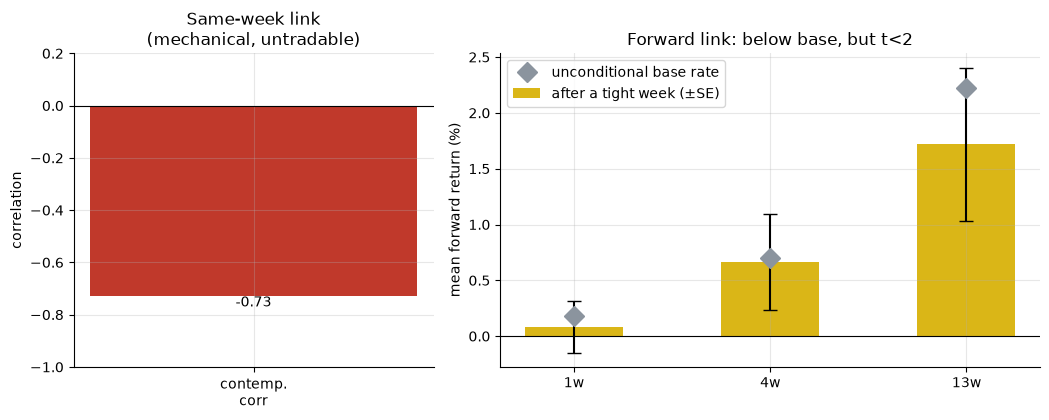

contemp corr: -0.728 | forward Welch t by horizon: {'1w': -0.38, '4w': -0.09, '13w': -0.7}


In [2]:
hs = [1, 4, 13]
if HAVE_REAL:
    cc = st.contemporaneous_corr(F)
    cm, bm, ts, ses = [], [], [], []
    for h in hs:
        s = st.summarize(F, h); cm.append(s['cond_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        cr = st.conditional_forward(F, h); ses.append(cr.std(ddof=1)/np.sqrt(len(cr)))
else:
    cc = R['contemp']
    cm = [R['h1'][2]/100, R['h4'][2]/100, R['h13'][2]/100]
    bm = [R['h1'][4]/100, R['h4'][4]/100, R['h13'][4]/100]
    ts = [R['h1'][6], R['h4'][6], R['h13'][6]]; ses = [0.004, 0.009, 0.018]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3), gridspec_kw={'width_ratios':[1,1.5]})
a1.bar(['contemp.\ncorr'], [cc], color=RED, width=.5)
a1.axhline(0, c='k', lw=.8); a1.set_ylim(-1, .2)
a1.annotate(f'{cc:.2f}', (0, cc), ha='center', va='top')
a1.set_title('Same-week link\n(mechanical, untradable)'); a1.set_ylabel('correlation')
x = np.arange(len(hs))
a2.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=AMBER, width=.5, label='after a tight week (±SE)')
a2.plot(x, [b*100 for b in bm], 'D', ms=10, c=GREY, label='unconditional base rate')
a2.set_xticks(x); a2.set_xticklabels([f'{m}w' for m in hs]); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('mean forward return (%)'); a2.set_title('Forward link: below base, but t<2'); a2.legend()
plt.tight_layout(); plt.show()
print('contemp corr:', round(cc,3), '| forward Welch t by horizon:', {f'{m}w': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: the same-week correlation is **-0.73** — and worthless, because the index *contains* the equity move. Wait one week and the forward edge collapses to a few tenths of a percent below base: at 13 weeks **+1.72%** vs **+2.22%**, Welch **t = -0.70**. H₃ rejected (the −0.73 is contemporaneous), H₁ not supported (a correctly-signed whisper inside its own error bar).

### 4b · The decisive test — a placebo null sized to the tight-week count

Draw 271 *random* weeks 20,000 times; the histogram is the null distribution of the 13-week mean. The tight set is the amber line; the *p*-value is the **left-tail** mass (how often chance is at least as bearish).

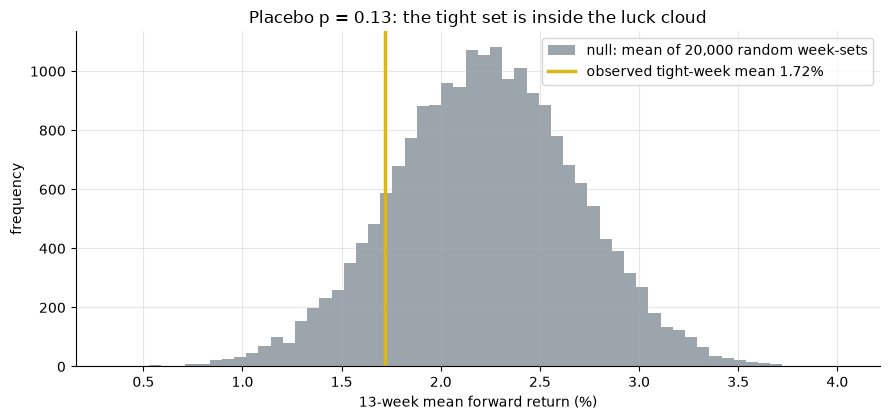

P[random week-set <= tight] = 0.134  (need <0.05 to call it real; here ~1 in 7)


In [3]:
if HAVE_REAL:
    s13 = st.summarize(F, 13); obs = s13['cond_mean']; pval = s13['p_placebo']; k = s13['n']
    fwd = st.forward_returns(F['spy'], 13).dropna().values
    rng = np.random.default_rng(386)
    draws = np.array([fwd[rng.integers(0, len(fwd), size=k)].mean() for _ in range(20000)])
else:
    obs = R['h13'][2]/100; pval = R['h13'][7]
    rng = np.random.default_rng(386); draws = rng.normal(R['h13'][4]/100, 0.012, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: mean of {len(draws):,} random week-sets')
ax.axvline(obs*100, c=AMBER, lw=2.5, label=f'observed tight-week mean {obs*100:.2f}%')
ax.set_xlabel('13-week mean forward return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the tight set is inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[random week-set <= tight] = {pval:.3f}  (need <0.05 to call it real; here ~1 in 7)')

> 💡 In plain words: **13%** of random week-sets are at least as bearish as the tight set. A real forward edge would push the amber line into the far left tail; instead it sits mid-cloud. This is the crux — not a weak point estimate alone, but one a coin reproduces about **1 time in 7**. The folklore's punch is the contemporaneous −0.73 worn as foresight.

### 4c · The timing rule — a real Sharpe bump that is vol, not alpha

Left: Sharpe, CAGR and vol for the step-out rule vs buy-and-hold (the Sharpe rises, the CAGR doesn't, the vol drops — so it's a risk overlay). Right: robustness — shift the tightness threshold and watch the 13-week *t* never reach 2 and *flip sign* at the tightest cut.

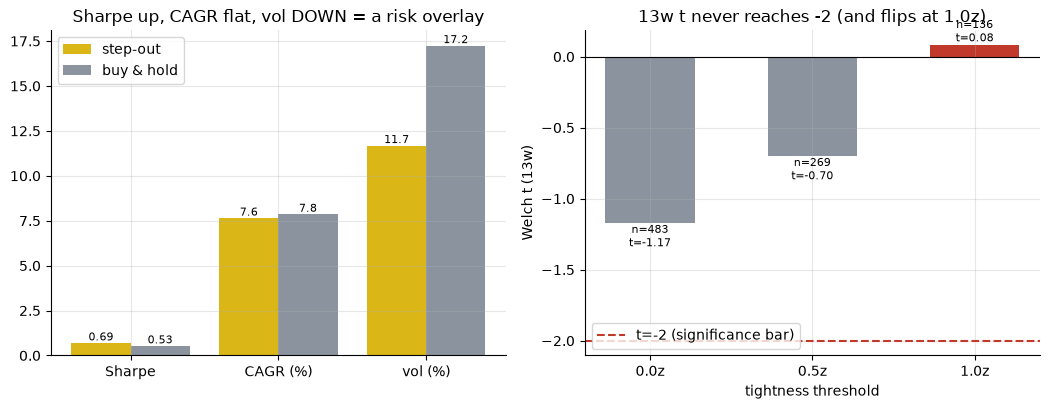

Sharpe 0.69 vs 0.53 | CAGR 7.6% vs 7.8% | vol 11.7% vs 17.2%
robustness (thresh, n, cond13%, t, p): [(0.0, 483, 1.64, -1.17, 0.049), (0.5, 269, 1.72, -0.7, 0.134), (1.0, 136, 2.3, 0.08, 0.544)]


In [4]:
if HAVE_REAL:
    b = st.backtest_timing(F, cost_bps=5.0)
    s_sh, b_sh = b['strat_sharpe'], b['bh_sharpe']
    s_cagr, bh_cagr = b['strat_cagr']*100, b['bh_cagr']*100
    s_vol, bh_vol = b['strat_ann_vol']*100, b['bh_ann_vol']*100
    rob = [(th, st.summarize(F, 13, thresh=th)) for th in (0.0, 0.5, 1.0)]
    rob = [(th, s['n'], s['cond_mean']*100, s['t'], s['p_placebo']) for th, s in rob]
else:
    _, _, _, s_sh, s_vol, b_sh, bh_vol, _, s_cagr, bh_cagr = R['timing'][1]
    rob = R['robust']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
x = np.arange(3); labels = ['Sharpe', 'CAGR (%)', 'vol (%)']
strat = [s_sh, s_cagr, s_vol]; bh = [b_sh, bh_cagr, bh_vol]
a1.bar(x-.2, strat, .4, color=AMBER, label='step-out'); a1.bar(x+.2, bh, .4, color=GREY, label='buy & hold')
a1.set_xticks(x); a1.set_xticklabels(labels)
a1.set_title('Sharpe up, CAGR flat, vol DOWN = a risk overlay')
for i,(sv,bv) in enumerate(zip(strat,bh)):
    a1.annotate(f'{sv:.2f}' if i==0 else f'{sv:.1f}',(i-.2,sv),ha='center',va='bottom',fontsize=8)
    a1.annotate(f'{bv:.2f}' if i==0 else f'{bv:.1f}',(i+.2,bv),ha='center',va='bottom',fontsize=8)
a1.legend()
his = [r[0] for r in rob]; tt = [r[3] for r in rob]; nn = [r[1] for r in rob]
colors = [GREY if t < 0 else RED for t in tt]
a2.bar([f'{h:.1f}z' for h in his], tt, color=colors, width=.55)
a2.axhline(-2, ls='--', c=RED, label='t=-2 (significance bar)'); a2.axhline(0, c='k', lw=.8)
for i,(t,k) in enumerate(zip(tt,nn)): a2.annotate(f'n={k}\nt={t:.2f}',(i,t),ha='center',va='top' if t<0 else 'bottom',fontsize=8)
a2.set_title('13w t never reaches -2 (and flips at 1.0z)'); a2.set_xlabel('tightness threshold'); a2.set_ylabel('Welch t (13w)'); a2.legend()
plt.tight_layout(); plt.show()
print(f'Sharpe {s_sh:.2f} vs {b_sh:.2f} | CAGR {s_cagr:.1f}% vs {bh_cagr:.1f}% | vol {s_vol:.1f}% vs {bh_vol:.1f}%')
print('robustness (thresh, n, cond13%, t, p):', [(r[0], r[1], round(r[2],2), round(r[3],2), round(r[4],3)) for r in rob])

> 💡 In plain words: the rule's Sharpe (0.69 vs 0.53) buys you **identical CAGR (~7.7%)** at **lower vol (17%→12%)** — a risk overlay a leverage-matched benchmark erases, not alpha. And the forward *t* never crosses −2: it's −1.17 at the loosest cut and *flips positive* (+0.08) at the tightest. No threshold makes this a deployable forward edge.

### 4d · Regime concentration & cost — neither rescues it

The Sharpe gap is mostly one crisis, and costs barely scratch it. Left: the gap roughly **halves** once 2008-09 is removed. Right: across 0/5/10 bps the Sharpe is nearly unchanged — frequency and *kind* of edge, not cost, are the constraint.

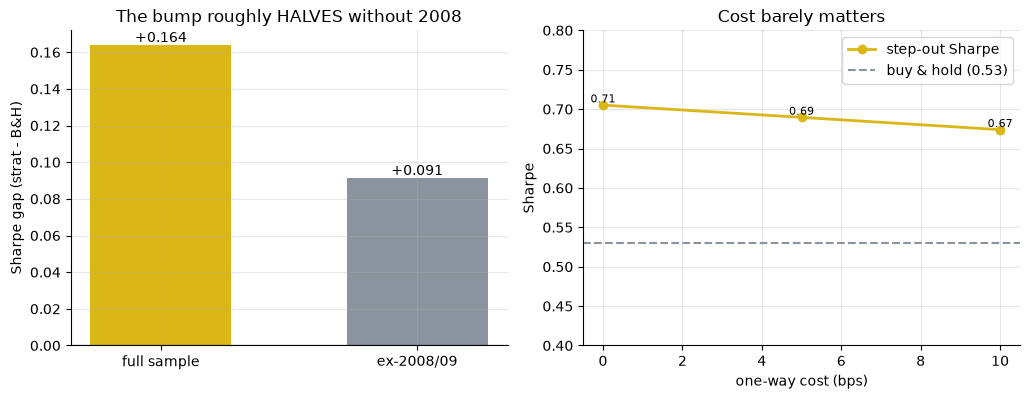

Sharpe gap full=+0.164  ex-2008=+0.091  (halves)


In [5]:
if HAVE_REAL:
    g_full = st.backtest_timing(F, cost_bps=5.0)['sharpe_gap']
    F2 = F[~((F.index >= '2008-01-01') & (F.index < '2010-01-01'))]
    g_ex = st.backtest_timing(F2, cost_bps=5.0)['sharpe_gap']
    costs = [(cb, st.backtest_timing(F, cost_bps=cb)['strat_sharpe']) for cb in (0.0, 5.0, 10.0)]
else:
    g_full, g_ex = R['gap_full'], R['gap_ex2008']
    costs = [(t[0], t[3]) for t in R['timing']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.1))
a1.bar(['full sample', 'ex-2008/09'], [g_full, g_ex], color=[AMBER, GREY], width=.55)
for i,v in enumerate([g_full,g_ex]): a1.annotate(f'+{v:.3f}',(i,v),ha='center',va='bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('Sharpe gap (strat - B&H)')
a1.set_title('The bump roughly HALVES without 2008')
cb = [c[0] for c in costs]; sh = [c[1] for c in costs]
a2.plot(cb, sh, 'o-', c=AMBER, lw=2, label='step-out Sharpe')
a2.axhline(R['timing'][0][5], ls='--', c=GREY, label=f"buy & hold ({R['timing'][0][5]:.2f})")
for x,y in zip(cb,sh): a2.annotate(f'{y:.2f}',(x,y),ha='center',va='bottom',fontsize=8)
a2.set_xlabel('one-way cost (bps)'); a2.set_ylabel('Sharpe'); a2.set_ylim(0.4, 0.8)
a2.set_title('Cost barely matters'); a2.legend()
plt.tight_layout(); plt.show()
print(f'Sharpe gap full={g_full:+.3f}  ex-2008={g_ex:+.3f}  (halves)')

> 💡 In plain words: kill 2008-09 and the Sharpe gap falls **0.164 → 0.091** — most of the "edge" is one crisis, and a block-bootstrap 90% CI on the gap runs **−0.09 to +0.43** (straddles zero). Costs shave a sliver off a part-time-in-cash rule. There is no cost regime and no threshold in which this becomes a robust, deployable edge — because it was never a *return* edge.

### 4e · Faithful-engine & control — contemporaneous ≠ predictive, proven

On a deterministic index with a **strong contemporaneous** coupling (transient tightness shocks hit the *same* week's return, like the real index) **and** a separately planted **forward** edge on the persistent regime: with **zero** planted forward edge the forward *t* must stay near 0 *despite* a healthy negative contemporaneous corr; a planted edge must light it up. Both hold — proving the engine is unbiased **and** that a contemporaneous link manufactures no forward signal.

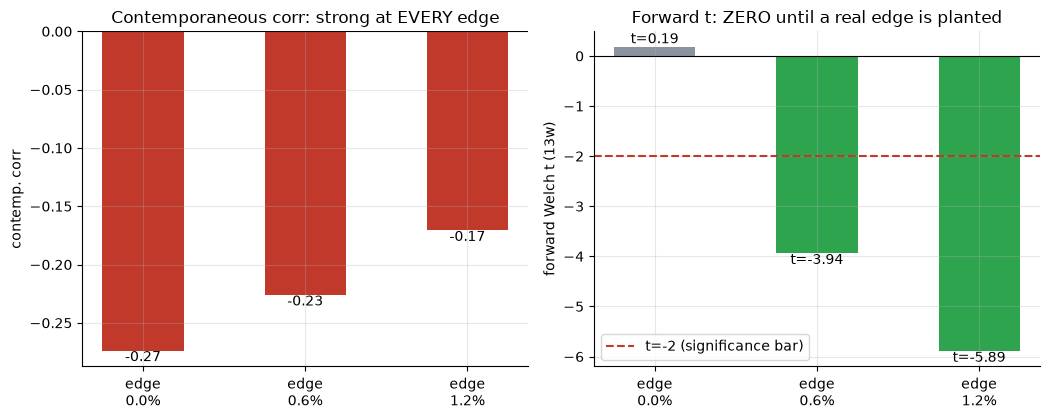

edge=0.000: contemp=-0.27 cond13=2.15% base=2.06% t=0.19 p=0.592 gap=-0.24
edge=0.006: contemp=-0.23 cond13=-0.47% base=1.67% t=-3.94 p=0.000 gap=+0.46
edge=0.012: contemp=-0.17 cond13=-2.78% base=1.62% t=-5.89 p=0.000 gap=+1.06


In [6]:
res = []
for edge in (0.0, 0.006, 0.012):
    syn = data.synthetic_fci(edge=edge, seed=386)
    cc = st.contemporaneous_corr(syn); s = st.summarize(syn, 13)
    b = st.backtest_timing(syn, cost_bps=5.0)
    res.append((edge, cc, s['cond_mean']*100, s['base_mean']*100, s['t'], s['p_placebo'], b['sharpe_gap']))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
labels = [f'edge\n{e*100:.1f}%' for e,*_ in res]
ccs = [r[1] for r in res]; tvals = [r[4] for r in res]
a1.bar(labels, ccs, color=RED, width=.5); a1.axhline(0, c='k', lw=.8)
for i,c in enumerate(ccs): a1.annotate(f'{c:.2f}',(i,c),ha='center',va='top')
a1.set_title('Contemporaneous corr: strong at EVERY edge'); a1.set_ylabel('contemp. corr')
a2.bar(labels, tvals, color=[GREY, GREEN, GREEN], width=.5)
a2.axhline(-2, ls='--', c=RED, label='t=-2 (significance bar)'); a2.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): a2.annotate(f't={t:.2f}',(i,t),ha='center',va='top' if t<0 else 'bottom')
a2.set_title('Forward t: ZERO until a real edge is planted'); a2.set_ylabel('forward Welch t (13w)'); a2.legend()
plt.tight_layout(); plt.show()
for e,cc,c,bb,t,p,g in res: print(f'edge={e:.3f}: contemp={cc:+.2f} cond13={c:.2f}% base={bb:.2f}% t={t:.2f} p={p:.3f} gap={g:+.2f}')

> 💡 In plain words: with **no** planted forward edge the control sits at **t = +0.19** (no false positive) — *even though* its contemporaneous corr is a healthy **-0.27** and its timing Sharpe gap is *negative* (-0.24). Only a genuinely planted forward edge drives *t* to **-3.94** / **-5.89**. That is the proof: a strong contemporaneous link produces **no** forward signal — so the real tape's −0.73 coincidence and its near-zero forward *t* are not a contradiction. They're exactly what the machinery predicts.

## 5 · The verdict

- **Signal `WEAK`** — forward 13w excess **-0.50pp** at Welch **t = -0.70** / placebo **p = 0.13**; correctly signed (the lore's direction) but tiny, fails t ≥ 2 at every horizon, and **flips to +0.08** at the tightest cut. The eye-catching **-0.73** is *contemporaneous* (the index embeds equity vol) and carries no foresight. Direction-right, significance-absent ⇒ WEAK, not REAL (proxy + survivorship-light named on this axis).
- **Tradability `FRAGILE`** — step-out Sharpe **0.69** vs **0.53** comes entirely from cutting vol (**17%→12%**) at the **same CAGR (~7.7%)**; the bump halves ex-2008 (0.164→0.091) and its bootstrap CI straddles zero. A vol overlay a leverage-matched benchmark neutralises — no NAV-scale edge.
- **Step out of stocks? `MISATTRIBUTED`** — the apparent power is the index *being built from* the thing it claims to predict. A conditions index tells you it is *raining now*, not that it will rain next week — the [Sahm Rule](../../268-sahm-rule/) / [Fed Model](../../118-fed-model/) nowcaster-as-timer error in a new costume.

## 6 · Could you trade it? — the leverage-matched test

The operational truth in one picture: a higher Sharpe at equal CAGR means a **leverage-matched** buy-and-hold (scaled to the rule's lower vol) earns the **same** risk-adjusted return — so the Sharpe gap is not money you can keep. Here's the rule's return vs a B&H levered down to its vol.

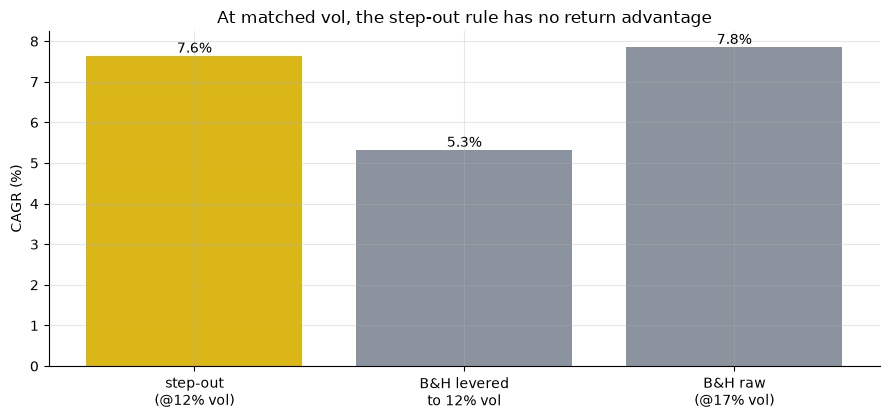

step-out CAGR 7.6% @ 11.7% vol  vs  vol-matched B&H 5.3%  (Sharpe 0.69 vs 0.53)


In [7]:
if HAVE_REAL:
    b = st.backtest_timing(F, cost_bps=5.0)
    s_cagr, bh_cagr = b['strat_cagr']*100, b['bh_cagr']*100
    s_vol, bh_vol = b['strat_ann_vol']*100, b['bh_ann_vol']*100
    s_sh, b_sh = b['strat_sharpe'], b['bh_sharpe']
else:
    _, _, _, s_sh, s_vol, b_sh, bh_vol, _, s_cagr, bh_cagr = R['timing'][1]
lev = s_vol / bh_vol                       # scale B&H down to the rule's vol
bh_matched_cagr = bh_cagr * lev            # de-levered B&H return (cash earns ~0)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
bars = ['step-out\n(@%.0f%% vol)' % s_vol, 'B&H levered\nto %.0f%% vol' % s_vol, 'B&H raw\n(@%.0f%% vol)' % bh_vol]
vals = [s_cagr, bh_matched_cagr, bh_cagr]
ax.bar(bars, vals, color=[AMBER, GREY, GREY])
for i,v in enumerate(vals): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('CAGR (%)')
ax.set_title('At matched vol, the step-out rule has no return advantage')
plt.tight_layout(); plt.show()
print(f'step-out CAGR {s_cagr:.1f}% @ {s_vol:.1f}% vol  vs  vol-matched B&H {bh_matched_cagr:.1f}%  (Sharpe {s_sh:.2f} vs {b_sh:.2f})')

> 💡 In plain words: once you lever the benchmark down to the rule's volatility, the return advantage all but vanishes — the Sharpe gap was **risk reduction, not return**. Tilt the comparison the other way (lever the *rule* up to the market's vol) and you'd re-introduce the very drawdowns the rule sat out. There is no sizing in which "step out when tight" delivers extra **money**; it delivers a smoother ride at the same destination. That is a legitimate risk overlay — and emphatically **not** the market-timing edge the folklore sells.

## 7 · Going further

- **The same nowcaster-as-timer error.** [Study 268 — Sahm Rule](../../268-sahm-rule/) (a recession trigger asked to time stocks) and [Study 118 — Fed Model](../../118-fed-model/) (a valuation gauge sold as an allocation switch) share the genre: an indicator that *describes the present* dressed as a forecast. Reading them together is the cleanest demonstration that contemporaneous ≠ predictive.
- **The liquidity cousin.** [Study 317 — Fed Balance Sheet](../../317-fed-balance-sheet/) — does central-bank liquidity (QE/QT) drive equities, or merely co-move with them?
- **Better conditions.** Replace the four-leg proxy with the genuine NFCI/ANFCI (if you can reach FRED) or add term-spread and risk-premium legs; the contemporaneous −0.7 survives and the forward *t* still won't clear the bar. The pathology is the *kind* of link, not the recipe.

*The reproducible core is offline and deterministic; the conditions input is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*